# Generic (e.g., non-linear) filtering
stough 202-

In this brief demo we use [`scipy.ndimage.filters.generic_filter`](https://docs.scipy.org/doc/scipy-0.16.1/reference/generated/scipy.ndimage.filters.generic_filter.html) to compute non-linear filters on an image, such as min/max/median and others. This works a lot more slowly than the `correlate` we used for the linear filters.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np

# For computing a generic filter on an image
from scipy.ndimage import generic_filter

# For importing from alternative directory sources
import sys  
sys.path.insert(0, '../dip_utils')

from matrix_utils import (arr_info,
                          make_linmap)
from vis_utils import (vis_rgb_cube,
                       vis_hists,
                       vis_pair)

## Define the generic filtering function we want
This function will be applied to every *footprint* or neighborhood in the image.

In [2]:
#simple blur
def mean_func(x):
    return x.mean()
#     xr = np.reshape(x, (5,5))
#     return np.mean(xr[:,3:])- np.mean(xr[:,:3])

def min_func(x):
    return x.min()

def max_func(x):
    return x.max()

def med_func(x):
    return np.median(x)

## Apply the function to each channel separately.
We could alternatively define the `footprint` or `size` to the `generic_filter` call to include the separate channels (e.g., `size = (3,3,3)`), but it's easier to think about this way.

We'll also normalize the image to float $[0,1]$ for visualization purposes.

In [3]:
I = plt.imread('../dip_pics/bellagio.jpg').astype('float')
I = I/I.max()
arr_info(I)

((687, 1024, 3), dtype('float64'), np.float64(0.0), np.float64(1.0))

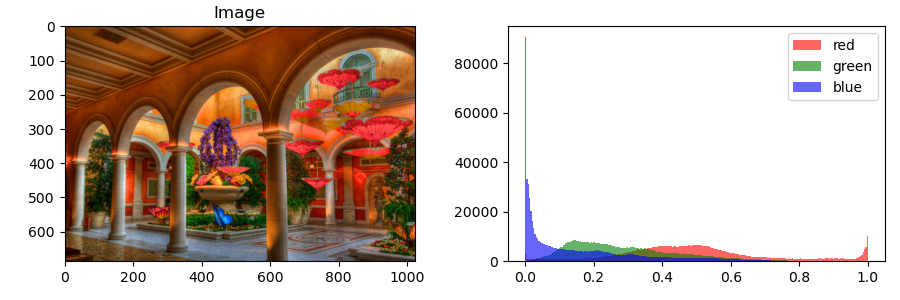

In [4]:
vis_hists(I)

In [7]:
If = np.zeros(I.shape)
Out = np.zeros(I.shape[:2])

for chan in range(3):
    generic_filter(I[:, :, chan], function=mean_func, size=11, output=Out, mode='reflect')
    If[...,chan] = Out.copy();

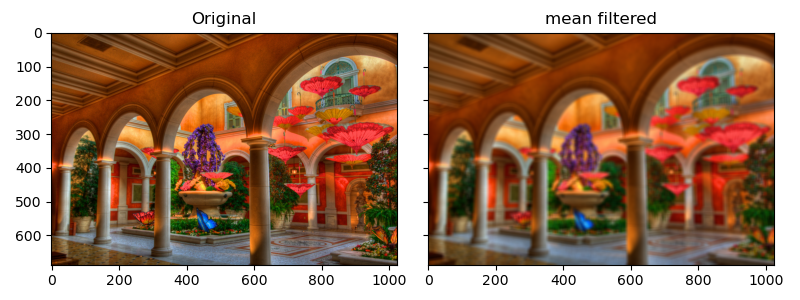

In [8]:
vis_pair(I, If, second_title="mean filtered")

## Now try one of the other local neighborhood functions
The mean is in fact a linear operator, so we're not really looking into what these local non-linear operators can do for us. Try one of the others, like min or median, or even better, **write one of your own**. Show the same closeup for the different operators and consider why they look different.